# EEE 2 Stage HPT
EEE stands for Energy Efficient Engine, initiated in the mid-1970s, it was aimed at developing a more fuel efficient turbofan engine for commercial aviation. Both Pratt and Whitney and General Electric developed a version of the engine with components. The components are still used in simulations today as benchmark tools.

The reports are in the eee_reference folder. GE developed a 2 stage HPT where Pratt developed a single stage. Most of the NASA reports and publications will reference the 2 stage HPT. The Geometry and simulation results were performed by Glenn and University of Cincinnati https://ntrs.nasa.gov/citations/20150003286

Simulations were done with Numeca CFD. Numeca can be expensive, their CFView Reader isn't free. In this tutorial, we perform simulations using ADS and release the Tecplot files of those simulations. The simulations were used to build a turbo-design model of the geometry using fixed pressure losses calculated from the simulation

Total Pressure loss equation for a turbine. 01 denotes total pressure upstream of the blade row. 02 is downstream. P2 is the static pressure at blade row exit.
$$
    P_{0,loss} = \frac{P_{01} - P_{02}}{P_{01}-P_{2}}
$$



## EEE Boundary Conditions
|       **Inlet**      | **Units** | **Value** |
|:--------------------:|:---------:|:---------:|
| P0                   | Pa        | 1257514   |
| T0                   | K         | 1587      |
|      **Rotors**      |           |           |
| RPM                  |           | 12400     |
|      **Outlet**      |           |           |
| Exit Static Pressure | Pa        | 230300    |



|                      | **Stator-1** | **Rotor-1** | **Stator-2** | **Rotor-2** |
|:--------------------:|:------------:|:-----------:|:------------:|:-----------:|
| **Number of Blades** | 46           | 76          | 48           | 70          |

In [1]:
!pip install turbo-design
!pip install pyiges[full]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 477.6/477.6 kB 18.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.3/19.3 MB 45.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.9/74.9 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 27.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/118.1 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.0/148.0 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.9/275.9 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 81.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 68.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.3/112.3 MB 7.5 MB/s eta 0:00:00


In [9]:
!git clone https://github.com/nasa/turbo-design.git

fatal: destination path 'turbo-design' already exists and is not an empty directory.


In [10]:
# Copy the geometry out
!cp -r turbo-design/examples/EEE-HPT/geometry .
!cp -r turbo-design/examples/EEE-HPT/eee_references .
!cp -r turbo-design/examples/EEE-HPT/*.py .
!cp turbo-design/examples/EEE-HPT/template.agf .
# %load_ext autoreload
# %autoreload 2
# Remove the source folder (Optional)
# !rm -r turbo-design

# Import iges code
The code below imports and processes the hub, shroud, and blade iges files.

In [1]:
import numpy as np
import os, pyiges, pickle
import matplotlib.pyplot as plt

def Process_HubShroud_IGES():
    """Exports hub and shroud curves in inches
    """
    iges_case = pyiges.read('geometry/case.igs')
    iges_hub = pyiges.read('geometry/hub.igs')

    # print an invidiual entity (boring)
    curve = iges_case.items[0].to_geomdl()
    curve.delta = 0.001
    case_pts = np.array(curve.evalpts)

    curve = iges_hub.items[0].to_geomdl()
    curve.delta = 0.001
    hub_pts = np.array(curve.evalpts)
    os.makedirs('csv',exist_ok=True)

    np.savetxt('csv/shroud.csv',case_pts,fmt="%f",delimiter=',',header='x,r,theta')
    np.savetxt('csv/hub.csv',hub_pts,fmt="%f",delimiter=',',header='x,r,theta')

    # Plot flowpath with improved styling
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(case_pts[:, 0], case_pts[:, 1], 'b-', linewidth=2, label='Shroud (Casing)')
    ax.plot(hub_pts[:, 0], hub_pts[:, 1], 'r-', linewidth=2, label='Hub')
    ax.fill_between(case_pts[:, 0], hub_pts[:, 1], case_pts[:, 1],
                    alpha=0.1, color='gray', label='Flow passage')
    ax.set_xlabel('Axial Position, x [inches]', fontsize=16)
    ax.set_ylabel('Radial Position, r [inches]', fontsize=16)
    ax.set_title('EEE 2-Stage HPT Flowpath (Meridional View)', fontsize=18, fontweight='bold')
    ax.legend(loc='center right', fontsize=12)
    ax.grid(True, linestyle='--', alpha=0.7)
    ax.set_aspect('equal', adjustable='box')
    ax.tick_params(axis='both', labelsize=12)
    fig.tight_layout()
    plt.savefig('flowpath.png', dpi=300, bbox_inches='tight')
    plt.close(fig)
    
    # Hub and Shroud are in inches
    pickle.dump({'Hub':hub_pts,'Shroud':case_pts},open('hub_shroud.pkl','wb'))

def Process_StatorRotor_IGES():
    """Exports stator and rotor curves in inches
    """
    # load an example impeller
    iges_rotor1 = pyiges.read('geometry/hpt_stator1.igs')
    iges_stator1 = pyiges.read('geometry/hpt_rotor1.igs')

    iges_rotor2 = pyiges.read('geometry/hpt_stator2.igs') # this is actually the rotor
    iges_stator2 = pyiges.read('geometry/hpt_rotor2.igs') # this is actually the stator
    curve_delta=0.001
    # Stage 1
    os.makedirs('csv',exist_ok=True)

    stator_pts1 = list(); indx = 1
    for i in range(2,7):
        curve = iges_stator1.items[i].to_geomdl()
        curve.delta=curve_delta
        points = np.array(curve.evalpts); n = points.shape[0]
        stator_pts1.append(points)
        os.makedirs('csv', exist_ok=True)
        np.savetxt(f'csv/stator1_{indx}.csv',points,fmt="%f",delimiter=',',header='x,rtheta,r')
        indx+=1

    # print an invidiual entity (boring)
    rotor_pts1 = list(); indx = 1
    for i in range(2,7):
        curve = iges_rotor1.items[i].to_geomdl()
        curve.delta=curve_delta
        points = np.array(curve.evalpts);
        rotor_pts1.append(points)
        np.savetxt(f'csv/rotor1_{indx}.csv',points,fmt="%f",delimiter=',',header='x,rtheta,r')
        indx+=1

    # Stage 2
    stator_pts2 = list(); indx = 1
    for i in range(2,6):
        curve = iges_stator2.items[i].to_geomdl()
        curve.delta=curve_delta
        points = np.array(curve.evalpts)
        stator_pts2.append(points)
        np.savetxt(f'csv/stator2_{indx}.csv',points,fmt="%f",delimiter=',',header='x,rtheta,r')
        indx+=1

    # print an invidiual entity (boring)
    rotor_pts2 = list(); indx = 1
    for i in range(2,7):
        curve = iges_rotor2.items[i].to_geomdl()
        curve.delta=curve_delta
        points = np.array(curve.evalpts)
        rotor_pts2.append(points)
        np.savetxt(f'csv/rotor2_{indx}.csv',points,fmt="%f",delimiter=',',header='x,rtheta,r')
        indx+=1

    pickle.dump([stator_pts1,rotor_pts1,stator_pts2,rotor_pts2],open('stator_rotor.pkl','wb'))

### Lets import the IGES Geometry
The code below calls the functions required to import the hub and shroud curves from the iges files provided. The second function imports the blades from the iges files.

In [2]:
from turbodesign import TurbineSpool, Inlet, RowType, BladeRow, Passage, Outlet, PassageType
from turbodesign.coolant import Coolant
import platform

if platform.system() != "Darwin": # pyiges[full] does not work on MacOS
    Process_HubShroud_IGES()        # units are in inches
    Process_StatorRotor_IGES()


## Processing the blade geometry
After the iges files have been imported they come as one single curve for the entire blade. It may become necessary to split the blade into suction and pressure side with equal number of points. Some CFD meshing tools require a split of suction and pressure sides in order to effectively generate the mesh for leading and trailing edge.

Lets load the function below

In [3]:
import numpy.typing as npt
from scipy.interpolate import PchipInterpolator
from typing import List, Tuple

# Import all plotting and geometry processing functions from the main script
# This avoids code duplication - functions are maintained in one place
from eee_hpt_process_geometry import (
    resample_curve,
    split_airfoil_by_angle_distance,
    plot_blade,
    plot_all_blades_combined,
    plot_xz,
    fit_blade
)

In [4]:
# Load the processed data
blades = pickle.load(open('stator_rotor.pkl','rb'))


In [5]:
# Plot some of the profiles
print("number of blades " + str(len(blades))) # This is stator,rotor, stator,rotor

stator1 = blades[0]
rotor1 = blades[1]
stator2 = blades[2]
rotor2 = blades[3]

print(f'Number of sections for stator1: {len(stator1)}')
print(f'Number of points for each section of stator1: {stator1[0].shape[0]}')

number of blades 4
Number of sections for stator1: 5
Number of points for each section of stator1: 1000


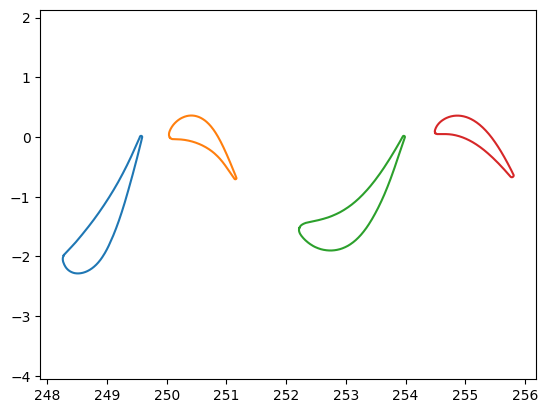

In [6]:
plt.figure()
plt.plot(stator1[0][:,0],stator1[0][:,1]) # X-Y plot of stator1
plt.plot(rotor1[0][:,0],rotor1[0][:,1]) # X-Y plot of rotor1
plt.plot(stator2[0][:,0],stator2[0][:,1]) # X-Y plot of stator2
plt.plot(rotor2[0][:,0],rotor2[0][:,1]) # X-Y plot of rotor2
plt.axis('equal')
plt.show()
# Note the blade is a single continous section at a z value

In [ ]:
# Note: All plotting and geometry processing functions are now imported from
# eee_hpt_process_geometry.py in an earlier cell (4ad070be) to avoid code duplication.
# 
# Imported functions:
# - resample_curve
# - split_airfoil_by_angle_distance  
# - plot_blade
# - plot_all_blades_combined
# - plot_xz
# - fit_blade
#
# Any updates to plotting functions should be made in eee_hpt_process_geometry.py

In [7]:
processed_data = []
npts = 400
for i,blade in enumerate(blades):
    nsections = len(blade)
    n,m = blade[0].shape
    ss = np.zeros(shape=(nsections,npts,m))
    ps = np.zeros(shape=(nsections,npts,m))
    for section_index in range(nsections):
        ss_temp, ps_temp = split_airfoil_by_angle_distance(blade[section_index],npts=npts)
        # plot_blade(ss,ps,'test')
        ss[section_index,:,:] = ss_temp
        ps[section_index,:,:] = ps_temp
    ss = ss[np.argsort(ss[:,0,2]),:,:]
    ps = ps[np.argsort(ps[:,0,2]),:,:]
    ss *= 25.4 # convert to mm
    ps *= 25.4 # convert to mm
    print(f'Blade-{i} has {nsections} sections')
    processed_data.append((ss, ps))

hub_shroud = pickle.load(open('hub_shroud.pkl','rb'))
hub = resample_curve(hub_shroud['Hub'],200) * 25.4          # Convert in to mm
shroud = resample_curve(hub_shroud['Shroud'],200) * 25.4

Blade-0 has 5 sections
Blade-1 has 5 sections
Blade-2 has 4 sections
Blade-3 has 5 sections


In [8]:
stator1 = processed_data[0]
print(f"Stator 1 suction side has {stator1[0].shape[0]} sections")
print(f"Stator 1 pressure side has {stator1[1].shape[0]} sections\n")

print(f"Stator 1 suction side section 0 has {stator1[0].shape[1]} points")
print(f"Stator 1 pressure side section 0 has {stator1[1].shape[1]} points")

# Plot individual blade with all spanwise sections
# Note: plot_blade now plots all sections with color gradient
plot_blade(stator1[0], stator1[1], 'Stator1', base_color='green')

Stator 1 suction side has 5 sections
Stator 1 pressure side has 5 sections

Stator 1 suction side section 0 has 400 points
Stator 1 pressure side section 0 has 400 points


In [9]:
# Resample the hub and shroud curves to include more points
hub_shroud = pickle.load(open('hub_shroud.pkl','rb'))
hub = resample_curve(hub_shroud['Hub'],200) * 25.4      # Resample and convert in to mm
shroud = resample_curve(hub_shroud['Shroud'],200) * 25.4


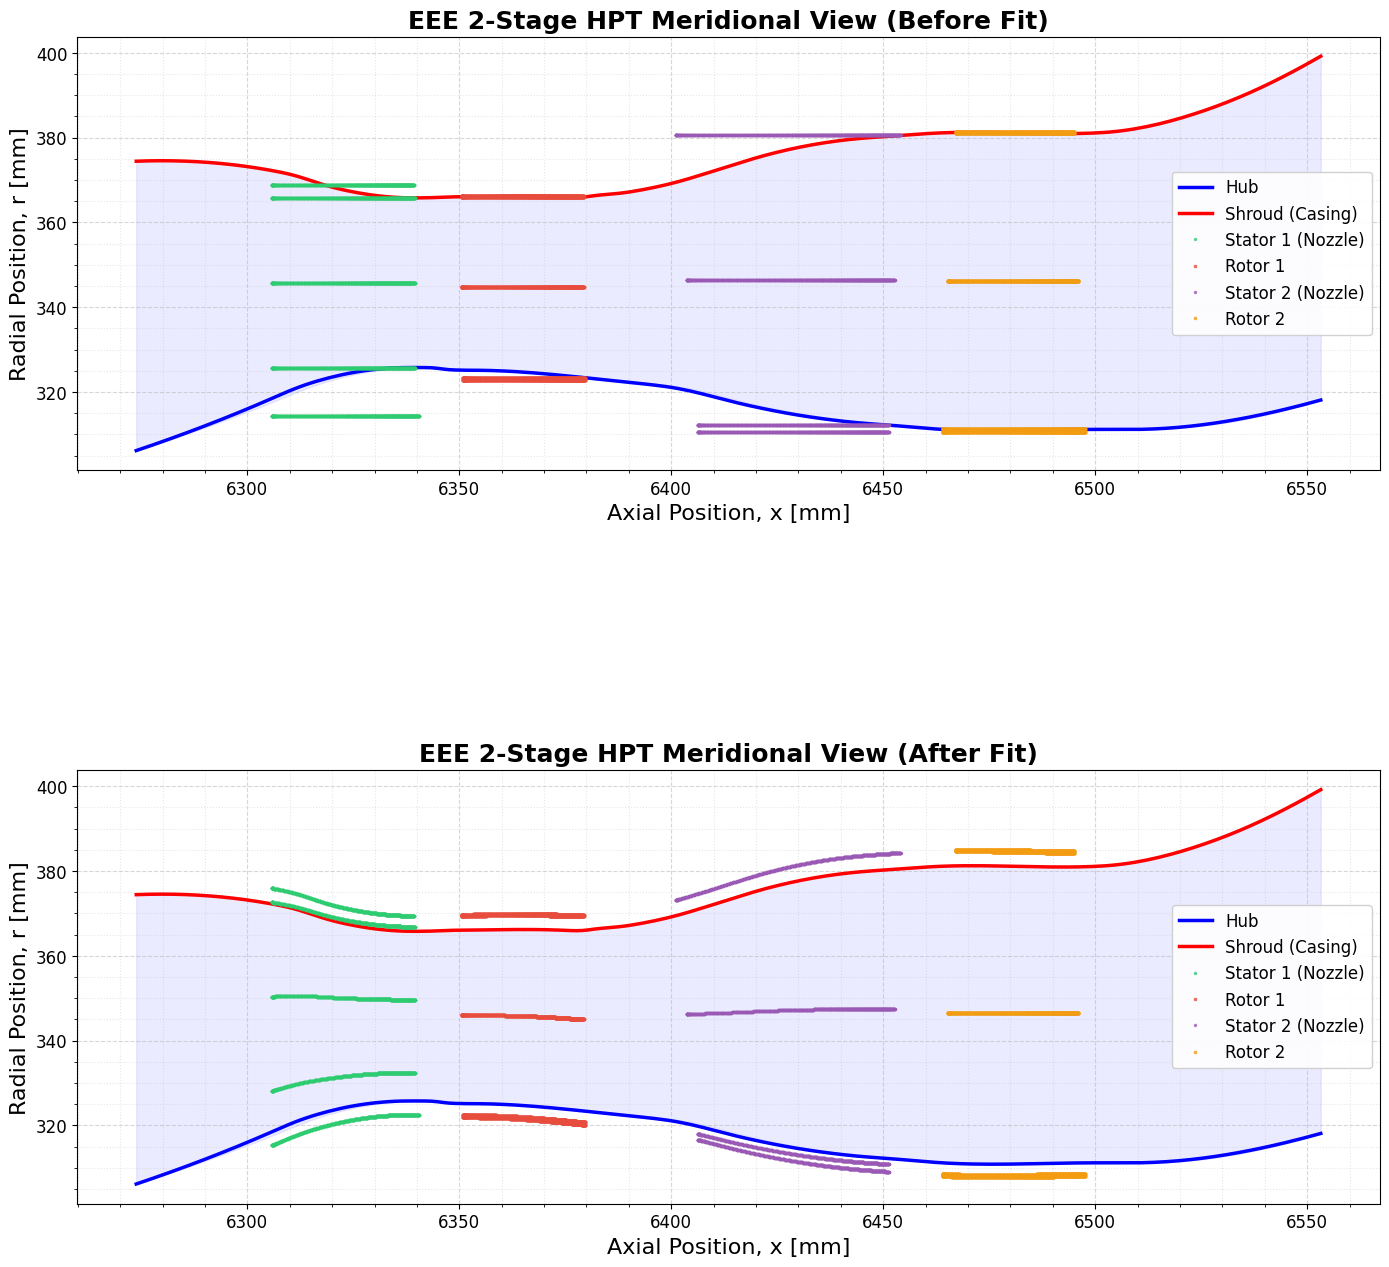

In [10]:
# Create a figure with vertical subplots for before/after fit comparison
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 16))

# Plot BEFORE fit
ax1.plot(hub[:, 0], hub[:, 1], 'b-', linewidth=2.5, label='Hub')
ax1.plot(shroud[:, 0], shroud[:, 1], 'r-', linewidth=2.5, label='Shroud (Casing)')
ax1.fill_between(shroud[:, 0], hub[:, 1], shroud[:, 1],
                alpha=0.08, color='blue')

colors = ['#2ecc71', '#e74c3c', '#9b59b6', '#f39c12']  # Green, Red, Purple, Orange
labels = ['Stator 1 (Nozzle)', 'Rotor 1', 'Stator 2 (Nozzle)', 'Rotor 2']
markers = ['o', 's', 'o', 's']  # Circles for stators, squares for rotors

for i, blade in enumerate(processed_data):
    ss = blade[0]
    ps = blade[1]
    color = colors[i % len(colors)]
    marker = markers[i % len(markers)]
    
    for j in range(ss.shape[0]):
        label = labels[i] if j == 0 else None
        ax1.plot(ss[j, :, 0], ss[j, :, 2], marker, color=color,
                markersize=1.5, alpha=0.7, label=label)
        ax1.plot(ps[j, :, 0], ps[j, :, 2], marker, color=color,
                markersize=1.5, alpha=0.7)

ax1.set_xlabel('Axial Position, x [mm]', fontsize=16)
ax1.set_ylabel('Radial Position, r [mm]', fontsize=16)
ax1.set_title('EEE 2-Stage HPT Meridional View (Before Fit)', fontsize=18, fontweight='bold')
ax1.legend(loc='center right', fontsize=12, framealpha=0.9)
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.set_aspect('equal', adjustable='box')
ax1.tick_params(axis='both', labelsize=12)
ax1.minorticks_on()
ax1.grid(which='minor', linestyle=':', alpha=0.3)

# Fit the blade into streamlines between hub and shroud
fit_blade(hub, shroud, processed_data)

# Plot AFTER fit
ax2.plot(hub[:, 0], hub[:, 1], 'b-', linewidth=2.5, label='Hub')
ax2.plot(shroud[:, 0], shroud[:, 1], 'r-', linewidth=2.5, label='Shroud (Casing)')
ax2.fill_between(shroud[:, 0], hub[:, 1], shroud[:, 1],
                alpha=0.08, color='blue')

for i, blade in enumerate(processed_data):
    ss = blade[0]
    ps = blade[1]
    color = colors[i % len(colors)]
    marker = markers[i % len(markers)]
    
    for j in range(ss.shape[0]):
        label = labels[i] if j == 0 else None
        ax2.plot(ss[j, :, 0], ss[j, :, 2], marker, color=color,
                markersize=1.5, alpha=0.7, label=label)
        ax2.plot(ps[j, :, 0], ps[j, :, 2], marker, color=color,
                markersize=1.5, alpha=0.7)

ax2.set_xlabel('Axial Position, x [mm]', fontsize=16)
ax2.set_ylabel('Radial Position, r [mm]', fontsize=16)
ax2.set_title('EEE 2-Stage HPT Meridional View (After Fit)', fontsize=18, fontweight='bold')
ax2.legend(loc='center right', fontsize=12, framealpha=0.9)
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.set_aspect('equal', adjustable='box')
ax2.tick_params(axis='both', labelsize=12)
ax2.minorticks_on()
ax2.grid(which='minor', linestyle=':', alpha=0.3)

fig.tight_layout()
plt.savefig('XZ_before_after_fit.png', dpi=300, bbox_inches='tight')
plt.show()

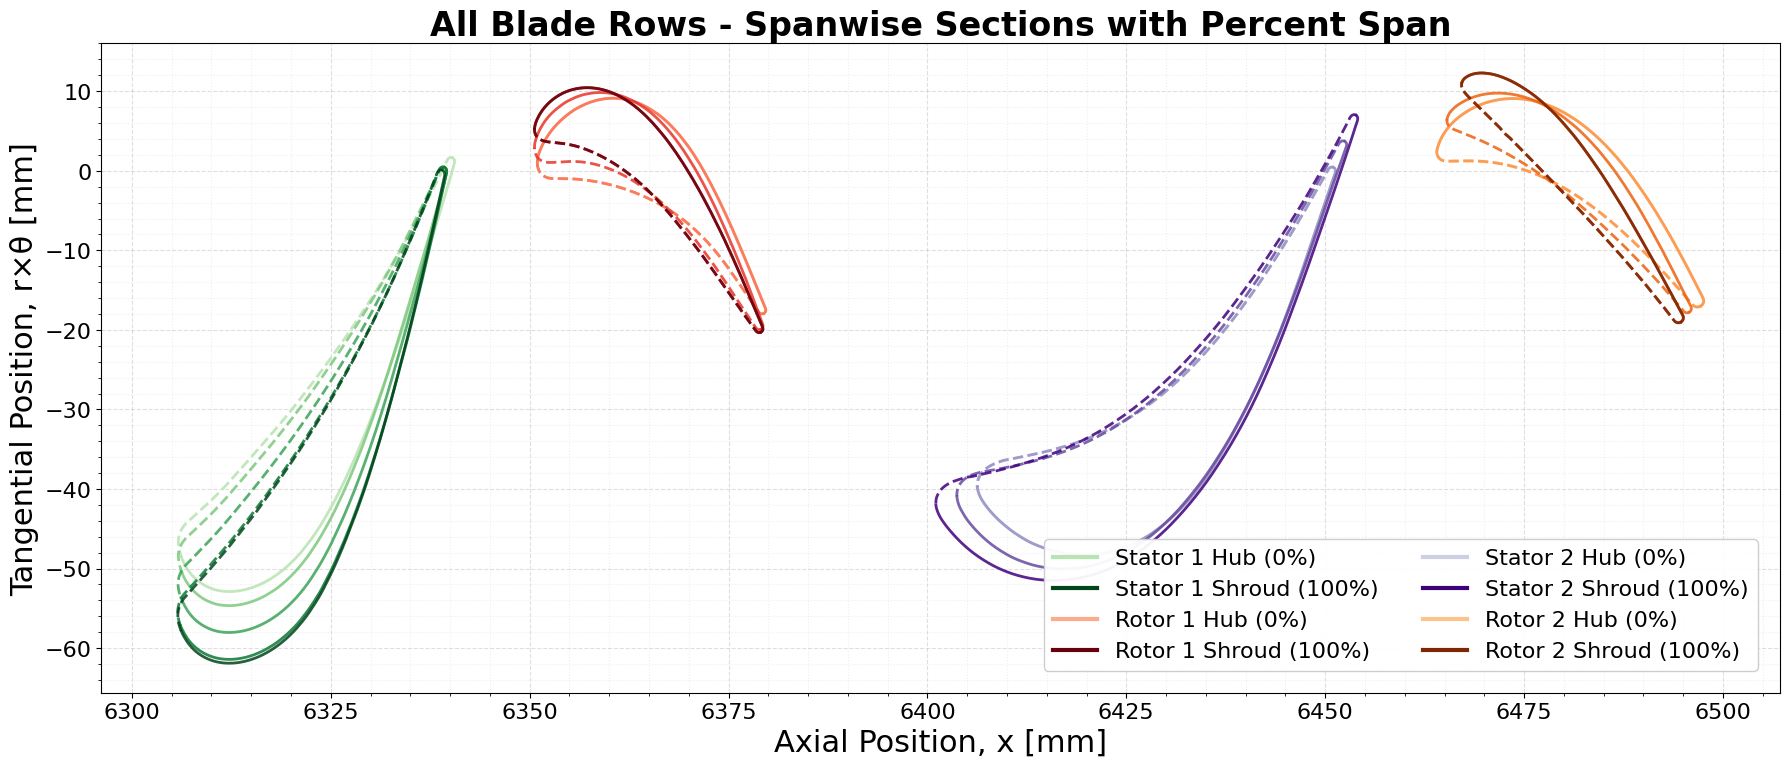

In [11]:
# Plot all blade rows combined on a single figure
# Colors match the meridional view: Green, Red, Purple, Orange
blade_names = ['Stator 1', 'Rotor 1', 'Stator 2', 'Rotor 2']
blade_colors = ['green', 'red', 'purple', 'orange']
plot_all_blades_combined(processed_data, blade_names, blade_colors)

## Creating the Aero Geometry File (AGF)
AGF is needed by Aerodynamic solutions solver to generate the mesh. This tutorial demonstrate the code required to construct this file but will not cover the meshing and solving as this would require a license.

In [22]:
from agf import Inlet_bcs, Outlet_bcs, Settings, AGF_Setup, Clearance

# Output the AGF Files for ADS
nblades = [46,76,48,70] # Vanes, Rotors, Vanes, Rotors
P0 = 1257514/1000       # kPa
T0 = 1587       # K
P = 230300/1000        # kPa

CorrectedSpeed = 33.19 # rad/(sec * sqrt(K))
RPM = 12400 # CorrectedSpeed * np.sqrt(T0) * 30/np.pi
RPM = [0,RPM,0,RPM]     # Stator - Rotor - Stator - Rotor
inlet = Inlet_bcs(ptin=P0,ttin=1588,machin=0.2,alpin=0,phiin=0,pspan=50)
clearance = Clearance(tlecl=0.000,tmccl=0.000,ttecl=0.000,hlecl=0,hmccl=0,htecl=0)

for i in range(len(processed_data)):
    ss = processed_data[i][0]; ps = processed_data[i][1]
    settings = Settings(ifang=0)
    settings.nblades = nblades[i]
    settings.ity = 5 # x,y,z
    settings.lete = 10
    outlet = Outlet_bcs(rpm=RPM[i],gamma=1.3,
                    psout=P,twall=0,molwt=28.96)
    agf = AGF_Setup(template_file='template.agf',name=f"EEE-HPT-{i}")
    agf.add_inlet(inlet=inlet)
    agf.add_outlet(outlet=outlet)
    agf.add_clearance(clearance=clearance)
    agf.add_settings(settings=settings)

    # cen.plot()
    agf.add_passage(hub=hub, shroud=shroud)
    agf.add_blade(ss,ps)
    agf.build(output_filename=f'blade{i}.agf')


# Turbo Design Model


## Massflow-Driven Design: Finding Blade Exit Angles

In turbomachinery design, there are two common approaches:

1. **Pressure Balance Mode** (default): Blade exit angles are fixed, and the solver adjusts static pressures to balance massflow between stages
2. **Angle Match Mode**: A target massflow is specified, and the solver adjusts blade exit angles to achieve that massflow

The second approach is particularly useful when:
- You have a target massflow from test data or CFD results
- You want to determine what blade angles would be needed to achieve a specific flow rate
- You're performing preliminary design where angles are not yet fixed

### Implementation

The key is how you initialize the outlet boundary condition:

```python
# Pressure Balance Mode (default)
outlet.init_static(P=exit_pressure, percent_radii=[0.5])

# Angle Match Mode (massflow-driven)
outlet.init_static(P=exit_pressure, percent_radii=[0.5], massflow=29.4)
```

When you specify the `massflow` parameter, TurboDesign automatically switches to angle matching mode and will adjust blade exit angles to match the specified massflow.

### Example: EEE HPT with FindBladeAngles Toggle

In the code cells above, notice the `FindBladeAngles` boolean flag. This demonstrates both modes:

**When `FindBladeAngles = True` (Angle Match Mode):**
- Outlet is initialized with: `outlet.init_static(P=P, percent_radii=[0.5], massflow=29.4)`
- Initial guess angles are used: `beta_exit_flow = [65, -65, 65, -65]`
- Solver adjusts angles to achieve 29.4 kg/s massflow
- You'll see: *"Using angle matching mode: blade exit angles will be adjusted to match specified massflow"*

**When `FindBladeAngles = False` (Pressure Balance Mode):**
- Outlet is initialized with: `outlet.init_static(P=P, percent_radii=[0.5])`
- Fixed angles from CFD are used: `beta_exit_flow = [73.6, -67.2, 69.5, -63.9]`
- Solver adjusts pressures to balance massflow
- You'll see: *"Using pressure balance mode: blade exit angles are fixed, static pressures will be adjusted"*

### Understanding the Results

When running in **Angle Match Mode**, the solver:
1. Starts with your initial guess angles (e.g., 65° for stators)
2. Iteratively adjusts the `beta2_metal` values to match the target massflow
3. Converges when the achieved massflow matches the target within tolerance

After running `.solve()`, check the results:

```python
# View the final blade exit angles
print(f"Stator 1 exit angle: {stator1.beta2_metal[0]:.1f}°")
print(f"Rotor 1 exit angle: {rotor1.beta2_metal[0]:.1f}°")

# Check achieved massflow
print(f"Achieved massflow: {inlet.total_massflow:.2f} kg/s")
print(f"Target massflow: {outlet.total_massflow:.2f} kg/s")
```

The exported JSON file will contain the final angles in the `beta2_metal` field for each blade row.

### Best Practices for Angle Matching

1. **Initial Guess**: Provide reasonable initial angle guesses within ±20° of expected values. Bad guesses can cause convergence issues

2. **Physical Constraints**: Ensure your target massflow is achievable:
   - Check that inlet total pressure and temperature support the desired flow rate
   - Verify exit pressure isn't unrealistically low/high
   - Consider choked flow limits

3. **Loss Models**: Angle matching works with all loss model types:
   - `FixedPressureLoss` (used in this example)
   - `AinleyMathieson`
   - `KackerOkapuu`
   - `CraigCox`, etc.

4. **Multi-Stage Machines**: The solver adjusts all blade row angles simultaneously to:
   - Match the overall target massflow
   - Balance massflow between stages
   - Maintain realistic velocity triangles

5. **Validation**: Always compare results with:
   - CFD simulations
   - Experimental data
   - Historical designs for similar applications

6. **Convergence**: If the solver doesn't converge:
   - Try different initial angle guesses
   - Check for unrealistic boundary conditions
   - Reduce the number of streamlines temporarily
   - Verify loss model coefficients are reasonable

In [12]:
from turbodesign import TurbineSpool, Inlet, RowType, BladeRow, Passage, Outlet, PassageType, Coolant
from turbodesign.row_factory import make_rotor_row, make_stator_row
from turbodesign.loss.fixedpressureloss import FixedPressureLoss
import numpy as np
from cantera import Solution
import pickle
from pathlib import Path
from scipy.interpolate import PchipInterpolator
# Geometry Import

# Set this to False to use the default blade angles; True means the blade angles are determined by matching the massflow
FindBladeAngles = True

blades = pickle.load(open('stator_rotor.pkl','rb'))

processed_data = []
npts = 400
for i,blade in enumerate(blades):
    nsections = len(blade)
    n,m = blade[0].shape
    ss = np.zeros(shape=(nsections,npts,m))
    ps = np.zeros(shape=(nsections,npts,m))
    for section_index in range(nsections):
        ss_temp, ps_temp = split_airfoil_by_angle_distance(blade[section_index],npts=npts)
        ss[section_index,:,:] = ss_temp
        ps[section_index,:,:] = ps_temp
    ss = ss[np.argsort(ss[:,0,2]),:,:]
    ps = ps[np.argsort(ps[:,0,2]),:,:]
    ss *= 25.4 # convert to mm
    ps *= 25.4 # convert to mm
    print(f'Blade-{i} has {nsections} sections')
    processed_data.append((ss, ps))

hub_shroud = pickle.load(open('hub_shroud.pkl','rb'))
x = np.linspace(hub_shroud['Hub'][:,0].min(),hub_shroud['Hub'][:,0].max(),200)

hub = np.vstack([x,PchipInterpolator(hub_shroud['Hub'][:,0],hub_shroud['Hub'][:,1])(x)]).transpose()
hub *= 25.4          # Convert in to mm

shroud = np.vstack([x,PchipInterpolator(hub_shroud['Shroud'][:,0],hub_shroud['Shroud'][:,1])(x)]).transpose()
shroud *= 25.4

# TurboDesign Setup
nblades = [46,76,48,70] # Vanes, Rotors, Vanes, Rotors
P0 = 1257450        # Pa
T0 = 1587           # K
P = 230.295*1000    # Pa
n_streamlines = 5

# Fluid
fluid = Solution('air.yaml')
fluid.TP = T0, P0 # Use pascal for cantera
print(f"Coefficient of Pressure [J/Kg] {fluid.cp:0.4f}")

#%% Defining the Inlet
inlet = Inlet(hub_location=0, alpha=[0, 0])
inlet.init_total(P0=[P0,P0],T0=[T0,T0],M=0.1)

outlet = Outlet(num_streamlines=n_streamlines)
if FindBladeAngles:
    # Find blade angles that meet a specific massflow requirement
    outlet.init_static(P=P,percent_radii=[0.5],massflow=29.4)
else:
    outlet.init_static(P=P,percent_radii=[0.5])

Blade-0 has 5 sections
Blade-1 has 5 sections
Blade-2 has 4 sections
Blade-3 has 5 sections
Coefficient of Pressure [J/Kg] 1218.0291


Lets setup the loss. For this example the data for Total Pressure Loss was extracted from the NASA EEE 2-Stage HPT Tecplot Simulation Release.
$$
    P_{0,Loss} = \frac{P_{01}-P_{02}}{P_{01}-P_{2}}
$$
where "0" denotes total condition. "01" refers to total condition upstream of the blade and 02 is downstream of the blade after the trailing edge. Single digit like "2" represent static condition.

In [13]:
# Axial chord and location calculations
cax1 = ( processed_data[0][0][0,:,0].max()-processed_data[0][0][0,:,0].min() )/1000
cax2 = ( processed_data[1][0][0,:,0].max()-processed_data[1][0][0,:,0].min() )/1000
cax3 = ( processed_data[2][0][0,:,0].max()-processed_data[2][0][0,:,0].min() )/1000
cax4 = ( processed_data[3][0][0,:,0].max()-processed_data[3][0][0,:,0].min() )/1000
location1 = (processed_data[0][0][0,:,0].max() - hub[:,0].min()) / (hub[:,0].max()-hub[:,0].min())
location2 = (processed_data[1][0][0,:,0].max() - hub[:,0].min()) / (hub[:,0].max()-hub[:,0].min())
location3 = (processed_data[2][0][0,:,0].max() - hub[:,0].min()) / (hub[:,0].max()-hub[:,0].min())
location4 = (processed_data[3][0][0,:,0].max() - hub[:,0].min()) / (hub[:,0].max()-hub[:,0].min())

print(f'Stator 1 Axial Chord {cax1*1000:0.2f} mm')
print(f'Rotor 1 Axial Chord {cax2*1000:0.2f} mm')
print(f'Stator 2 Axial Chord {cax3*1000:0.2f} mm')
print(f'Rotor 2 Axial Chord {cax4*1000:0.2f} mm')

print(f'Stator 1 Exit Location along hub as percent {location1:0.2f}')
print(f'Rotor 1 Exit Location along hub as percent {location2:0.2f}')
print(f'Stator 2 Exit Location along hub as percent {location3:0.2f}')
print(f'Rotor 2 Exit Location along hub as percent {location4:0.2f}')

# Blade exit angles - depends on mode
if FindBladeAngles:
    # Initial guess angles for angle matching mode
    beta_exit_flow = [65,-65,65,-65]
else:
    # Fixed angles from CFD for pressure balance mode
    beta_exit_flow = [73.6,-67.2,69.5,-63.9]

# Total pressure loss coefficients from CFD
P0_Loss = [0.057,0.088,0.069,0.014]  # (P01-P02)/(P01-P2)

Stator 1 Axial Chord 34.33 mm
Rotor 1 Axial Chord 28.72 mm
Stator 2 Axial Chord 45.03 mm
Rotor 2 Axial Chord 33.55 mm
Stator 1 Exit Location along hub as percent 0.24
Rotor 1 Exit Location along hub as percent 0.38
Stator 2 Exit Location along hub as percent 0.64
Rotor 2 Exit Location along hub as percent 0.80


Using angle matching mode: blade exit angles will be adjusted to match specified massflow
Looping to converge massflow (angle matching)
Angle match iteration 1, massflow std: 0.000011
Angle match iteration 2, massflow std: 0.383393
Angle match iteration 3, massflow std: 0.000015
Angle match iteration 4, massflow std: 0.000013
Angle match iteration 5, massflow std: 0.000002
Angle match iteration 6, massflow std: 0.000016
Angle match iteration 7, massflow std: 0.000012
Angle match iteration 8, massflow std: 0.000007
Angle match iteration 9, massflow std: 0.000014
Angle match iteration 10, massflow std: 0.000015


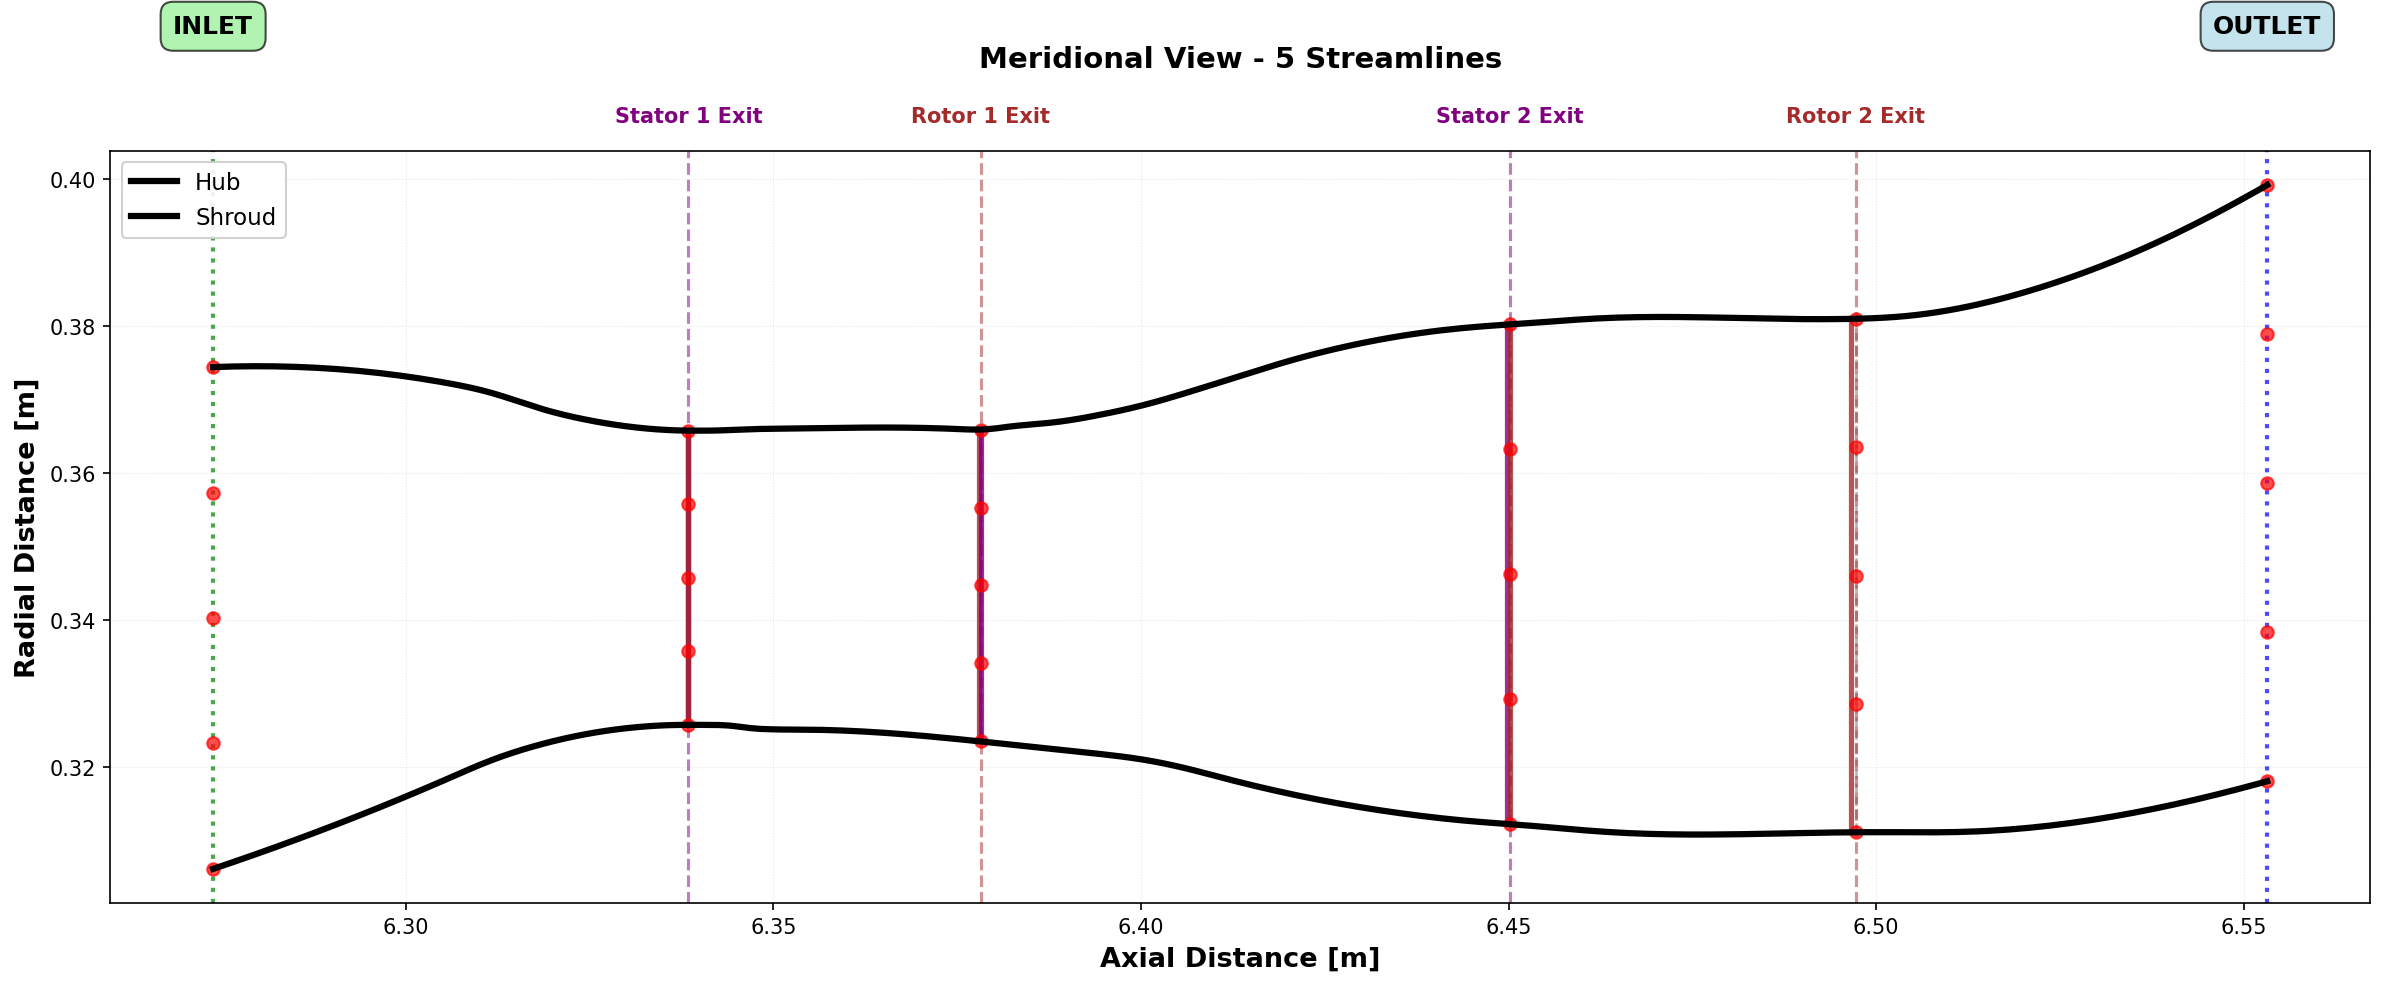

In [14]:
# Axial location is a percentage along the hub where row exit is defined
stator1 = make_stator_row(hub_location=location1)
rotor1 = make_rotor_row(hub_location=location2)
stator2 = make_stator_row(hub_location=location3)
rotor2 = make_rotor_row(hub_location=location4)

stator1.axial_chord = cax1 # Set an axial chord
rotor1.axial_chord = cax2
stator2.axial_chord = cax3
rotor2.axial_chord = cax4

inlet.gamma = 1.30
stator1.gamma = 1.30
rotor1.gamma = 1.32
stator2.gamma = 1.33
rotor2.gamma = 1.39

inlet.Cp = inlet.gamma/(inlet.gamma-1) * 287.15
stator1.Cp = stator1.gamma/(stator1.gamma-1) * 287.15
rotor1.Cp = rotor1.gamma/(rotor1.gamma-1) * 287.15
stator2.Cp = stator2.gamma/(stator2.gamma-1) * 287.15
rotor2.Cp = rotor2.gamma/(rotor2.gamma-1) * 287.15

stator1.stage_id = 0; rotor1.stage_id = 0
stator2.stage_id = 1; rotor2.stage_id = 1

# Coolant Definition: Use Kelvin and Pascal. Coolant only needs P0, T0, massflow, and Cp
stator1.coolant = Coolant(T0=T0*0.6, P0= P0, massflow_percentage=0,Cp=fluid.cp)
rotor1.coolant = Coolant(T0=T0*0.6, P0=P0,massflow_percentage=0,Cp=fluid.cp)
stator2.coolant = Coolant(T0=T0*0.6, P0=P0, massflow_percentage=0,Cp=fluid.cp)
rotor2.coolant = Coolant(T0=T0*0.6, P0=P0,massflow_percentage=0,Cp=fluid.cp)

# Add in turning angles
stator1.beta2_metal = [beta_exit_flow[0] for _ in range(n_streamlines)]        # Angle, hub,mean,tip
rotor1.beta2_metal = [beta_exit_flow[1] for _ in range(n_streamlines)]
stator2.beta2_metal = [beta_exit_flow[2] for _ in range(n_streamlines)]
rotor2.beta2_metal = [beta_exit_flow[3] for _ in range(n_streamlines)]


# These are all guessed values
stator1.loss_model = FixedPressureLoss(P0_Loss[0])  # type: ignore
rotor1.loss_model = FixedPressureLoss(P0_Loss[1])   # type: ignore
stator2.loss_model = FixedPressureLoss(P0_Loss[2])  # type: ignore
rotor2.loss_model = FixedPressureLoss(P0_Loss[3])   # type: ignore
hub_m = hub/1000
shroud_m = shroud/1000
passage = Passage(hub_m[:,0],hub_m[:,1],
                 shroud_m[:,0],shroud_m[:,1],
                 passageType=PassageType.Axial) # type: ignore

spool = TurbineSpool(passage=passage,
            massflow=20,
            inlet=inlet,
            outlet=outlet,
            rows=[stator1,rotor1,stator2,rotor2],
            rpm=12400,
            num_streamlines=n_streamlines,
            fluid=None)
spool.adjust_streamlines = False
spool.solve() # This also initializes streamlines
spool.export_properties("eee_results.json")
spool.plot()
spool.plot_velocity_triangles()